In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
conn = sqlite3.connect('olist.db')

In [3]:
csv_files = [
    'data/customers.csv',
    'data/orders.csv',
    'data/order_items.csv',
    'data/products.csv',
    'data/sellers.csv',
    'data/order_payments.csv',
    'data/order_reviews.csv',
    'data/geolocation.csv',
    'data/product_category_name_translation.csv'
]

for file in csv_files:
    table_name = os.path.splitext(os.path.basename(file))[0]
    df = pd.read_csv(file)
    df.to_sql(table_name, conn, if_exists='replace', index=False)

In [4]:
pd.read_sql("SELECT NAME FROM sqlite_master WHERE type='table';", conn)

,name
0,customers
1,orders
2,order_items
3,products
4,sellers
5,order_payments
6,order_reviews
7,geolocation
8,product_category_name_translation


In [5]:
pd.read_sql("SELECT * FROM ORDERS LIMIT 5", conn)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [6]:
pd.read_sql("SELECT * FROM CUSTOMERS LIMIT 5", conn)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [7]:
pd.read_sql("SELECT * FROM ORDER_ITEMS LIMIT 5", conn)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [8]:
pd.read_sql("SELECT * FROM PRODUCTS LIMIT 5", conn)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [9]:
pd.read_sql("SELECT * FROM ORDER_REVIEWS LIMIT 5", conn)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,None,None,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,None,None,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,None,None,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,None,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,None,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [10]:
review_count = pd.read_sql('SELECT REVIEW_SCORE, COUNT(*) AS review_score_count FROM ORDER_REVIEWS GROUP BY REVIEW_SCORE', conn)
review_count

,review_score,review_score_count
0,1,11424
1,2,3151
2,3,8179
3,4,19142
4,5,57328


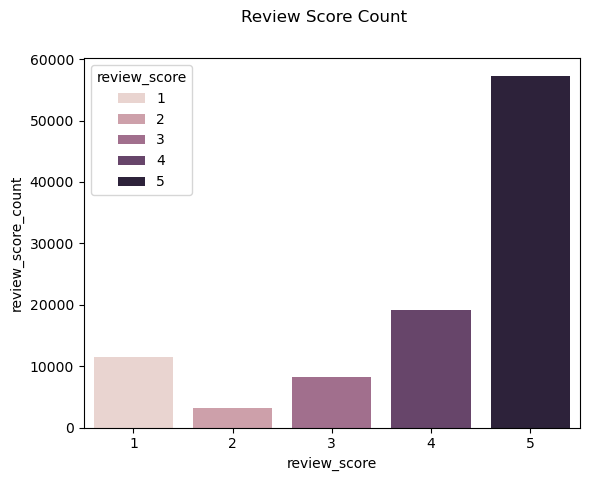

In [11]:
sns.barplot(data=review_count,x='review_score',y='review_score_count',hue='review_score')
fig = plt.gcf()
fig.suptitle('Review Score Count');

In [12]:
pd.read_sql("PRAGMA table_info(orders);", conn)

,cid,name,type,notnull,dflt_value,pk
0,0,order_id,TEXT,0,None,0
1,1,customer_id,TEXT,0,None,0
2,2,order_status,TEXT,0,None,0
3,3,order_purchase_timestamp,TEXT,0,None,0
4,4,order_approved_at,TEXT,0,None,0
5,5,order_delivered_carrier_date,TEXT,0,None,0
6,6,order_delivered_customer_date,TEXT,0,None,0
7,7,order_estimated_delivery_date,TEXT,0,None,0


In [13]:
query = '''
SELECT 
    r.review_score,
    o.order_delivered_customer_date,
    o.order_estimated_delivery_date,
    ROUND(JULIANDAY(o.order_delivered_customer_date) - JULIANDAY(o.order_estimated_delivery_date)) AS delay_days
FROM order_reviews AS r
JOIN orders AS o
ON r.order_id = o.order_id
WHERE o.order_delivered_customer_date IS NOT NULL
'''
df_delay = pd.read_sql(query,conn)
df_delay

,review_score,order_delivered_customer_date,order_estimated_delivery_date,delay_days
0,4,2017-10-10 21:25:13,2017-10-18 00:00:00,-7.0
1,4,2018-08-07 15:27:45,2018-08-13 00:00:00,-5.0
2,5,2018-08-17 18:06:29,2018-09-04 00:00:00,-17.0
3,5,2017-12-02 00:28:42,2017-12-15 00:00:00,-13.0
4,5,2018-02-16 18:17:02,2018-02-26 00:00:00,-9.0
...,...,...,...,...
96354,5,2017-03-17 15:08:01,2017-03-28 00:00:00,-10.0
96355,4,2018-02-28 17:37:56,2018-03-02 00:00:00,-1.0
96356,5,2017-09-21 11:24:17,2017-09-27 00:00:00,-6.0
96357,2,2018-01-25 23:32:54,2018-02-15 00:00:00,-20.0


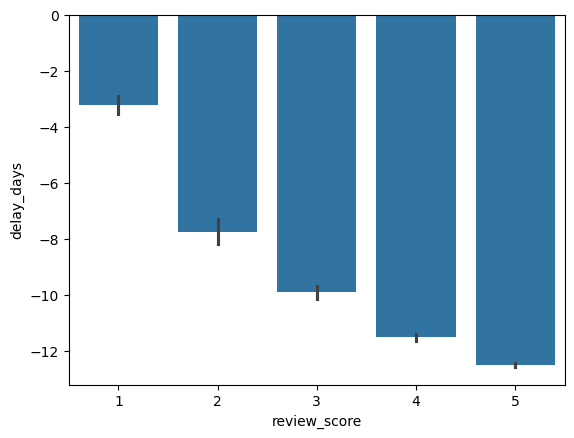

In [14]:
sns.barplot(data=df_delay, x='review_score',y='delay_days');

In [19]:
pd.read_sql('SELECT * FROM product_category_name_translation LIMIT 5',conn)

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [24]:
query = '''
SELECT
    i.order_id,
    i.price,
    t.product_category_name_english,
    r.review_score
FROM order_items AS i
JOIN products AS p
ON i.product_id = p.product_id
JOIN order_reviews AS r
ON i.order_id = r.order_id
JOIN product_category_name_translation AS t
ON p.product_category_name = t.product_category_name
'''
df = pd.read_sql(query,conn)
df

,order_id,price,product_category_name_english,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,cool_stuff,5
1,00018f77f2f0320c557190d7a144bdd3,239.90,pet_shop,4
2,000229ec398224ef6ca0657da4fc703e,199.00,furniture_decor,5
3,00024acbcdf0a6daa1e931b038114c75,12.99,perfumery,4
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,garden_tools,5
...,...,...,...,...
110745,fffc94f6ce00a00581880bf54a75a037,299.99,housewares,5
110746,fffcd46ef2263f404302a634eb57f7eb,350.00,computers_accessories,5
110747,fffce4705a9662cd70adb13d4a31832d,99.90,sports_leisure,5
110748,fffe18544ffabc95dfada21779c9644f,55.99,computers_accessories,5


In [33]:
df_avg_score = df.groupby('product_category_name_english').agg({'review_score':'mean'}).reset_index().sort_values('review_score',ascending=True).head(15)
df_avg_score

,product_category_name_english,review_score
61,security_and_services,2.500000
23,diapers_and_hygiene,3.256410
57,office_furniture,3.493183
46,home_comfort_2,3.629630
30,fashion_male_clothing,3.641221
34,fixed_telephony,3.683206
58,party_supplies,3.767442
27,fashio_female_clothing,3.780000
41,furniture_mattress_and_upholstery,3.815789
4,audio,3.825485


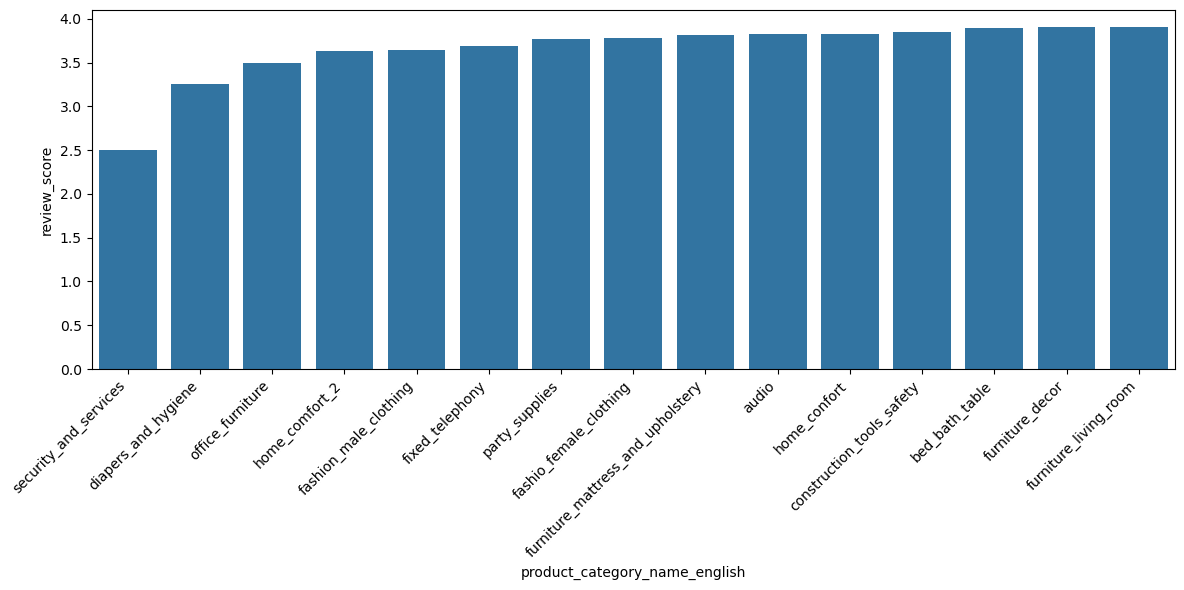

In [37]:
plt.figure(figsize=(12,6))
sns.barplot(data = df_avg_score, x='product_category_name_english', y='review_score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

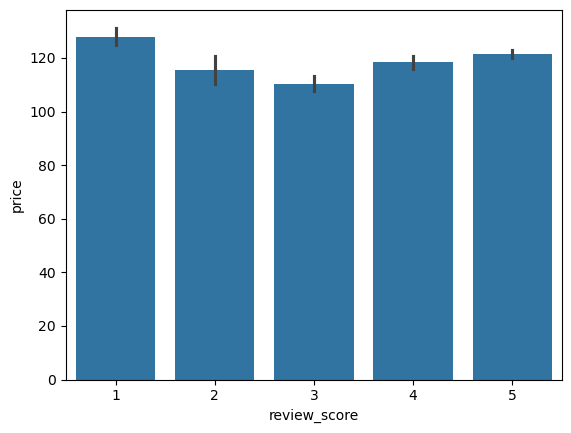

In [47]:
sns.barplot(data=df, x='review_score', y='price');

In [52]:
df_low_reviews = pd.read_sql("SELECT review_score, review_comment_message FROM order_reviews WHERE review_score in ('1','2') LIMIT 5",conn)
df_low_reviews

,review_score,review_comment_message
0,1,None
1,2,"GOSTARIA DE SABER O QUE HOUVE, SEMPRE RECEBI E..."
2,1,Péssimo
3,1,Não gostei ! Comprei gato por lebre
4,1,Sempre compro pela Internet e a entrega ocorre...


In [53]:
df_low_reviews.isna().sum()

review_score              0
review_comment_message    1
dtype: int64

In [58]:
df_low_reviews = df_low_reviews.fillna('').assign(review_comment_message=lambda df:df.review_comment_message.str.lower())

In [59]:
from collections import Counter

In [61]:
words = " ".join(df_low_reviews['review_comment_message']).split()
counter = Counter(words)

In [64]:
counter

Counter({'o': 4,
         'e': 3,
         'prazo': 3,
         'que': 2,
         'sempre': 2,
         'recebi': 2,
         'não': 2,
         'gostaria': 1,
         'de': 1,
         'saber': 1,
         'houve,': 1,
         'essa': 1,
         'compra': 1,
         'agora': 1,
         'me': 1,
         'decpcionou': 1,
         'péssimo': 1,
         'gostei': 1,
         '!': 1,
         'comprei': 1,
         'gato': 1,
         'por': 1,
         'lebre': 1,
         'compro': 1,
         'pela': 1,
         'internet': 1,
         'a': 1,
         'entrega': 1,
         'ocorre': 1,
         'antes': 1,
         'do': 1,
         'combinado,': 1,
         'acredito': 1,
         'ser': 1,
         'máximo.': 1,
         'no': 1,
         'stark': 1,
         'máximo': 1,
         'já': 1,
         'se': 1,
         'esgotou': 1,
         'ainda': 1,
         'produto.': 1})

In [79]:
query = '''
SELECT 
    o.order_id,
    ROUND(JULIANDAY(o.order_delivered_customer_date) - JULIANDAY(o.order_estimated_delivery_date)) AS delay_days,
    i.price,
    r.review_score
FROM ORDERS AS o
JOIN ORDER_ITEMS AS i
ON o.order_id = i.order_id
JOIN ORDER_REVIEWS AS r
ON o.order_id = r.order_id
'''

In [81]:
df = pd.read_sql(query,conn)
df

,order_id,delay_days,price,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,-7.0,29.99,4
1,53cdb2fc8bc7dce0b6741e2150273451,-5.0,118.70,4
2,47770eb9100c2d0c44946d9cf07ec65d,-17.0,159.90,5
3,949d5b44dbf5de918fe9c16f97b45f8a,-13.0,45.00,5
4,ad21c59c0840e6cb83a9ceb5573f8159,-9.0,19.90,5
...,...,...,...,...
112367,63943bddc261676b46f01ca7ac2f7bd8,-1.0,174.90,4
112368,83c1379a015df1e13d02aae0204711ab,-6.0,205.99,5
112369,11c177c8e97725db2631073c19f07b62,-20.0,179.99,2
112370,11c177c8e97725db2631073c19f07b62,-20.0,179.99,2


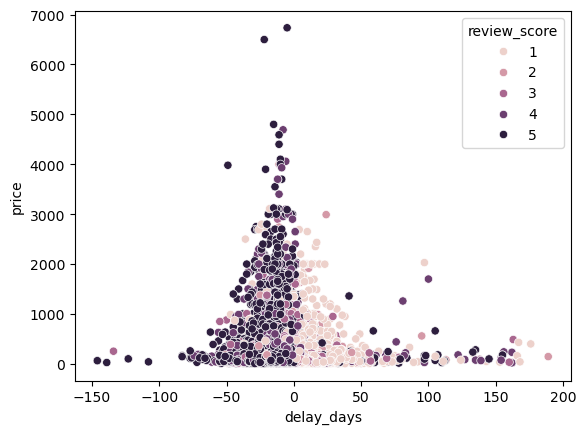

In [83]:
sns.scatterplot(data=df, x='delay_days', y='price', hue='review_score');

In [92]:
df.delay_days.describe()

count    110012.000000
mean        -11.202260
std          10.098708
min        -146.000000
25%         -16.000000
50%         -12.000000
75%          -7.000000
max         189.000000
Name: delay_days, dtype: float64

In [108]:
query = '''
SELECT 
    o.order_id,
    ROUND(JULIANDAY(o.order_delivered_customer_date) - JULIANDAY(o.order_estimated_delivery_date)) AS delay_days,
    t.product_category_name_english,
    r.review_score
FROM ORDERS AS o
JOIN ORDER_REVIEWS AS r
ON o.order_id = r.order_id
JOIN ORDER_ITEMS AS i
ON o.order_id = i.order_id
JOIN PRODUCTS AS p
ON i.product_id = p.product_id
JOIN product_category_name_translation AS t
ON p.product_category_name = t.product_category_name
'''

In [109]:
df = pd.read_sql(query,conn)
df

,order_id,delay_days,product_category_name_english,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,-7.0,housewares,4
1,53cdb2fc8bc7dce0b6741e2150273451,-5.0,perfumery,4
2,47770eb9100c2d0c44946d9cf07ec65d,-17.0,auto,5
3,949d5b44dbf5de918fe9c16f97b45f8a,-13.0,pet_shop,5
4,ad21c59c0840e6cb83a9ceb5573f8159,-9.0,stationery,5
...,...,...,...,...
110745,63943bddc261676b46f01ca7ac2f7bd8,-1.0,baby,4
110746,83c1379a015df1e13d02aae0204711ab,-6.0,home_appliances_2,5
110747,11c177c8e97725db2631073c19f07b62,-20.0,computers_accessories,2
110748,11c177c8e97725db2631073c19f07b62,-20.0,computers_accessories,2


In [110]:
len(set(df.product_category_name_english))

71

In [142]:
df_top10 = df.product_category_name_english.value_counts().head(10).index.tolist()
df_top10

['bed_bath_table',
 'health_beauty',
 'sports_leisure',
 'furniture_decor',
 'computers_accessories',
 'housewares',
 'watches_gifts',
 'telephony',
 'garden_tools',
 'auto']

In [143]:
df_top = df.query('product_category_name_english in @df_top10')
df_top

,order_id,delay_days,product_category_name_english,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,-7.0,housewares,4
2,47770eb9100c2d0c44946d9cf07ec65d,-17.0,auto,5
5,a4591c265e18cb1dcee52889e2d8acc3,-6.0,auto,4
6,6514b8ad8028c9f2cc2374ded245783f,-11.0,auto,5
7,76c6e866289321a7c93b82b54852dc33,-31.0,furniture_decor,1
...,...,...,...,...
110743,880675dff2150932f1601e1c07eadeeb,-16.0,furniture_decor,5
110744,9c5dedf39a927c1b2549525ed64a053c,-10.0,health_beauty,5
110747,11c177c8e97725db2631073c19f07b62,-20.0,computers_accessories,2
110748,11c177c8e97725db2631073c19f07b62,-20.0,computers_accessories,2


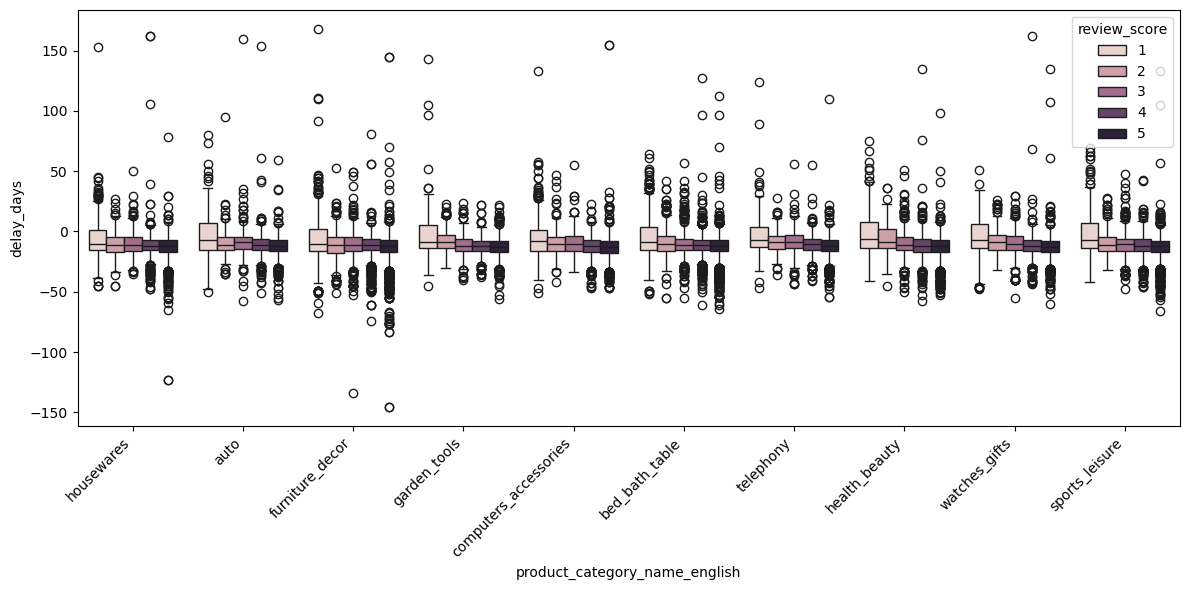

In [150]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_top,
    x="product_category_name_english",
    y="delay_days",
    hue="review_score"
)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [152]:
df[['delay_days','review_score']].corr()

,delay_days,review_score
delay_days,1.000000,-0.228358
review_score,-0.228358,1.000000


In [158]:
df.assign(delayed = lambda df:df.delay_days>0).merge

,order_id,delay_days,product_category_name_english,review_score,delayed,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,-7.0,housewares,4,False,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,-5.0,perfumery,4,False,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,-17.0,auto,5,False,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,-13.0,pet_shop,5,False,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,-9.0,stationery,5,False,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [161]:
pd.read_sql("SELECT * FROM customers LIMIT 5", conn)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [159]:
pd.read_sql("SELECT * FROM geolocation LIMIT 5", conn)

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [172]:
query = '''
SELECT 
    o.order_id,
    ROUND(JULIANDAY(o.order_delivered_customer_date) - JULIANDAY(o.order_estimated_delivery_date)) AS delay_days,
    c.customer_city,
    r.review_score
FROM ORDERS AS o
JOIN ORDER_REVIEWS AS r
ON o.order_id = r.order_id
JOIN CUSTOMERS AS c
ON o.customer_id = c.customer_id
'''

In [202]:
df_delay_rate=pd.read_sql(query,conn).query('delay_days.notna()').assign(delay = lambda df:df.delay_days>0).groupby('customer_city').agg(delay=("delay","mean"), n=("delay","size")).query("n >= 30").sort_values('delay',ascending=False)
df_delay_rate

,delay,n
customer_city,,
santarem,0.348837,43
maracanau,0.303030,33
maceio,0.289362,235
porto seguro,0.256410,39
itaperuna,0.255319,47
...,...,...
osorio,0.000000,35
capao da canoa,0.000000,38
capivari,0.000000,32


In [209]:
top_cities = df_delay_rate.head(5).index.tolist()
top_cities

['santarem', 'maracanau', 'maceio', 'porto seguro', 'itaperuna']

In [210]:
bottom_cities = df_delay_rate.tail(5).index.tolist()
bottom_cities

['osorio', 'capao da canoa', 'capivari', 'uruguaiana', 'campo largo']

In [214]:
pd.read_sql(query,conn).query('delay_days.notna()').query('customer_city in @top_cities').review_score.mean()

3.619647355163728

In [215]:
pd.read_sql(query,conn).query('delay_days.notna()').query('customer_city in @bottom_cities').review_score.mean()

4.391534391534392